<div class="alert alert-block alert-info">
Singapore Management University<br>
CS105 Statistical Thinking for Data Science, 2025/26 Term 2
</div>

# CS105 Group Project Submission (Part I)

-----
Provide your team details, including section, team number, team members, and the name of the dataset. 
Complete all of the following sections. For any part requiring code to derive your answers, please create a code cell immediately below your response and run the code.
To edit any markdown cell, double click the cell; after editing, execute the markdown cell to collapse it.
<br>
-----

## Declaration

<span style="color:red">By submitting this notebook, we declare that **no part of this submission is generated by any AI tool**. We understand that AI-generated submissions will be considered as plagiarism, and just like other plagirisum cases, disciplinary actions will be imposed.</span>

#### Section: 
#### Team: 
#### Members:
1. 
2. 
3. 
4. 
5. 

#### Dataset: 

## Part I: Exploratory Data Analysis (EDA) [8% of final grade]

### 1. Overview of dataset [15% of Part I]

**a.** Summarise the background of the dataset [limited to 50 words]

**Response.** 

**b.** State the size of the dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('housing.csv')
n_rows, n_cols = df.shape
print(f"# of rows is {n_rows}")
print(f"# of columns is {n_cols}")


# of rows is 506
# of columns is 14


**Response.** 

**c.** For each variable, describe what it represents and its data type (numerical or categorical)

**Response.**

In [3]:
df.dtypes

ID                         int64
Crime_Rate                object
Residential_Area          object
Non_Retail               float64
River                     object
Pollutants               float64
Rooms                    float64
Old_Housing              float64
Distance_Office          float64
Highway_Access            object
Tax_Rate                   int64
Student_Teacher_Ratio    float64
Low_Income               float64
Price                    float64
dtype: object

### 2. Data pre-processing [35% of Part I]

**a.** For each variable, determine the percentage of missing data. For any column with missing data, describe how you resolve the issue. Clearly state any assumption you made.

**Response.** 

In [4]:
n_rows, n_cols = df.shape
print("Percentage Missing Data")
1.0 - df.count() / n_rows

Percentage Missing Data


ID                       0.000000
Crime_Rate               0.045455
Residential_Area         0.000000
Non_Retail               0.000000
River                    0.000000
Pollutants               0.000000
Rooms                    0.000000
Old_Housing              0.000000
Distance_Office          0.000000
Highway_Access           0.000000
Tax_Rate                 0.000000
Student_Teacher_Ratio    0.000000
Low_Income               0.043478
Price                    0.000000
dtype: float64

Impute the "Crime_Rate" column using the mode of Crime_Rate across the dataset. 

In [5]:
crime_rate_mode = df.Crime_Rate.mode()[0] 
df.Crime_Rate.value_counts()  

Crime_Rate
Low         367
Moderate    100
High         16
Name: count, dtype: int64

The mode of Crime_Rate is "Low". So we assume that rows without Crime_Rate data is assumed to have a Low Crime_Rate.

In [6]:
df['Crime_Rate'] = df['Crime_Rate'].fillna(crime_rate_mode)
df.count()

ID                       506
Crime_Rate               506
Residential_Area         506
Non_Retail               506
River                    506
Pollutants               506
Rooms                    506
Old_Housing              506
Distance_Office          506
Highway_Access           506
Tax_Rate                 506
Student_Teacher_Ratio    506
Low_Income               484
Price                    506
dtype: int64

Drop the rows without income data as it is hard to determine income of household.

In [7]:
# drop low income household
df.dropna(inplace=True)
df.count()

ID                       484
Crime_Rate               484
Residential_Area         484
Non_Retail               484
River                    484
Pollutants               484
Rooms                    484
Old_Housing              484
Distance_Office          484
Highway_Access           484
Tax_Rate                 484
Student_Teacher_Ratio    484
Low_Income               484
Price                    484
dtype: int64

**b.** For each variable, identify outliers (if any) and describe how you resolve the issue. Clearly state any assumption you made.

In [ ]:
#need to do outliers?

**Response.** 

**c.** For categorical variables, perform the necessary encoding.

In [10]:
# encoding "River" to "0" (Near) and "1" (Far)
encoding = {"Near":0, "Far":1}
df["River_Encoded"] = df["River"].map(encoding)

# encoding "Crime_Rate" and "Highway_Access_Encoded" to "0" (Low), "1" (Moderate) and "2" (High)
encoding = {"Low": 0, "Moderate":1, "High": 2}
df["Crime_Rate_Encoded"] = df["Crime_Rate"].map(encoding)
df["Highway_Access_Encoded"] = df["Highway_Access"].map(encoding)

# encoding "Residential_Area" to "0" (Very Low), "1" (Low), "2" (Moderate), "3" (High), "4" (Very High)
encoding = {"Very Low": 0, "Low": 1, "Moderate": 2, "High": 3, "Very High": 4}
df["Residential_Area_Encoded"] = df["Residential_Area"].map(encoding)

df

,ID,Crime_Rate,Residential_Area,Non_Retail,River,Pollutants,Rooms,Old_Housing,Distance_Office,Highway_Access,Tax_Rate,Student_Teacher_Ratio,Low_Income,Price,River_Encoded,Crime_Rate_Encoded,Highway_Access_Encoded,Residential_Area_Encoded
0,1,Low,Very Low,2.31,Far,0.538,6.575,65.2,4.0900,Low,296,15.3,4.98,24.0,1,0,0,0
1,2,Low,Very Low,7.07,Far,0.469,6.421,78.9,4.9671,Low,242,17.8,9.14,21.6,1,0,0,0
2,3,Low,Very Low,7.07,Far,0.469,7.185,61.1,4.9671,Low,242,17.8,4.03,34.7,1,0,0,0
3,4,Low,Very Low,2.18,Far,0.458,6.998,45.8,6.0622,Low,222,18.7,2.94,33.4,1,0,0,0
4,5,Low,Very Low,2.18,Far,0.458,7.147,54.2,6.0622,Low,222,18.7,5.33,36.2,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,502,Low,Very Low,11.93,Far,0.573,6.593,69.1,2.4786,Low,273,21.0,9.67,22.4,1,0,0,0
502,503,Low,Very Low,11.93,Far,0.573,6.120,76.7,2.2875,Low,282,21.0,9.08,20.6,1,0,0,0
503,504,Low,Very Low,11.93,Far,0.573,6.976,91.0,2.1675,Low,273,21.0,5.64,23.9,1,0,0,0
504,505,Low,Very Low,11.93,Far,0.573,6.794,89.3,2.3889,Low,273,21.0,6.48,22.0,1,0,0,0


**Response.** 

### 3.	Exploratory analysis and visualization [50% of Part I]

**a.** For each variable, provide relevant summary statistics

**Response.** 

**b.** For each variable, provide an appropriate visualisation depicting the distribution of its values, and summarize any key observation(s) you made.

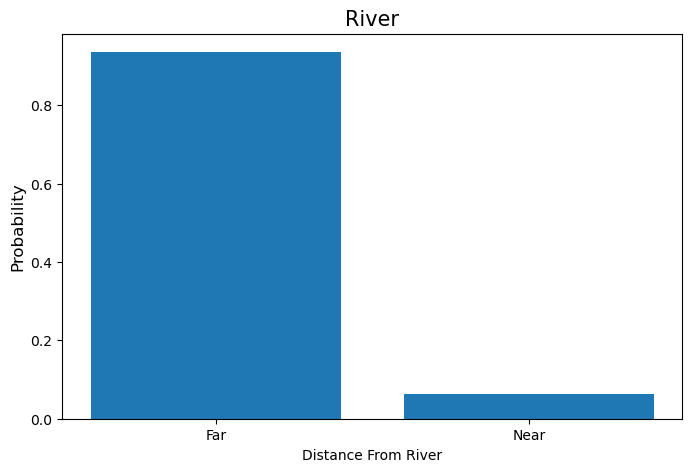

In [11]:
df["River"] = df["River"].astype(str)
data = df["River"].value_counts(normalize=True)

xs = data.index
ys = data

plt.figure(figsize=(8,5))
plt.bar(xs, ys)
plt.title("River", fontsize=15)
plt.xlabel("Distance From River")
plt.ylabel("Probability", fontsize=12)
plt.show()

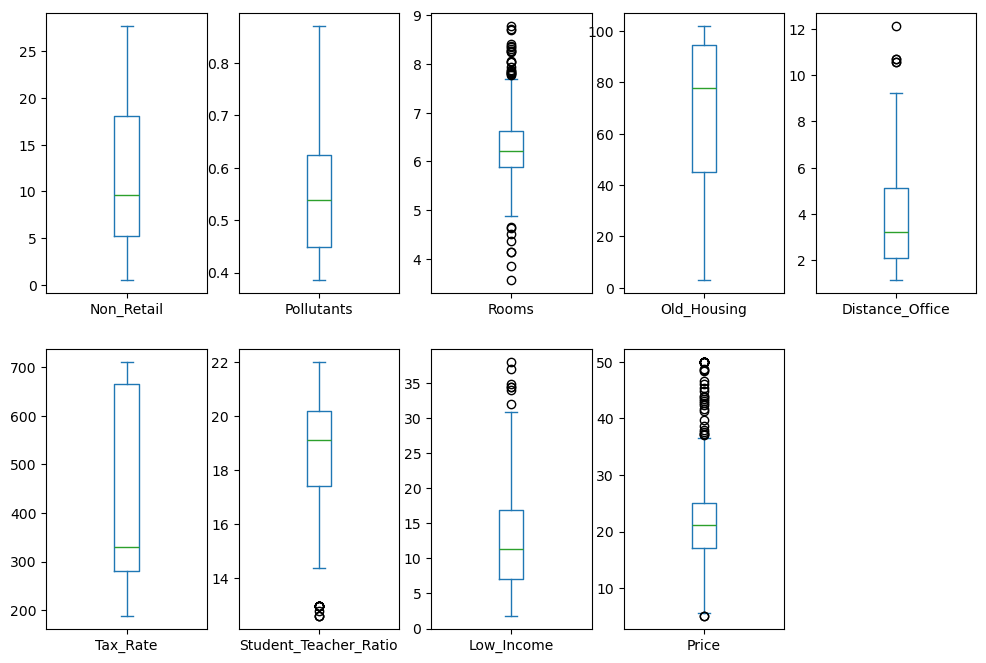

In [12]:
df_numerics = df[["Non_Retail","Pollutants","Rooms","Old_Housing","Distance_Office","Tax_Rate","Student_Teacher_Ratio", "Low_Income", "Price"]]
df_numerics.plot(kind='box',  subplots=True, layout=(2, 5), figsize=(12, 8))
plt.show()

In [13]:
print(f"mean Non_Retail: {df.Non_Retail.mean()}")
print(f"mean Pollutants: {df.Pollutants.mean()}")
print(f"median Rooms: {df.Rooms.median()}")
print(f"mean Old_Housing: {df.Old_Housing.mean()}")
print(f"mean Distance: {df.Distance_Office.mean()}")
print(f"mean Tax_Rate: {df.Tax_Rate.mean()}")
print(f"mean Student_Teacher_Ratio: {df.Student_Teacher_Ratio.mean()}")
print(f"mean Low_Incom: {df.Low_Income.mean()}")
print(f"mean Price: {df.Price.mean()}")

mean Non_Retail: 11.073946280991734
mean Pollutants: 0.5548421487603306
median Rooms: 6.211
mean Old_Housing: 69.11652892561982
mean Distance: 3.7984438016528927
mean Tax_Rate: 408.254132231405
mean Student_Teacher_Ratio: 18.464876033057852
mean Low_Incom: 12.626714876033057
mean Price: 22.556404958677685


**Response.** 

**c.** Perform bi-variate analysis on the variables. You do not need to present the analysis of every pair of variables; only focus on the pairs you believe are worth investigating and explain. For each pair, describe the relationship between the two variables. Use appropriate statistical methods and/or visualizations.

**Response.** 

We use this table to denote the strength of a relationship based on the correlation coefficient.

| r value  | Interpretation         |
| -------- | ---------------------- |
| 0        | No linear relationship |
| ±0.1–0.3 | Weak                   |
| ±0.3–0.5 | Moderate               |
| ±0.5–0.7 | Strong                 |
| ±0.7+    | Very strong            |

### Variables versus Price
First, we analysed the variables that affect the median price of homes (Price).

#### 1. Rooms
From the scatter plot, as the number of rooms increases, the price also increases.
Additionally, the correlation coefficient is 0.689 (3sf), suggesting a strong positive linear relationship.

Logically, this makes sense as houses with more rooms tend to cost more. 

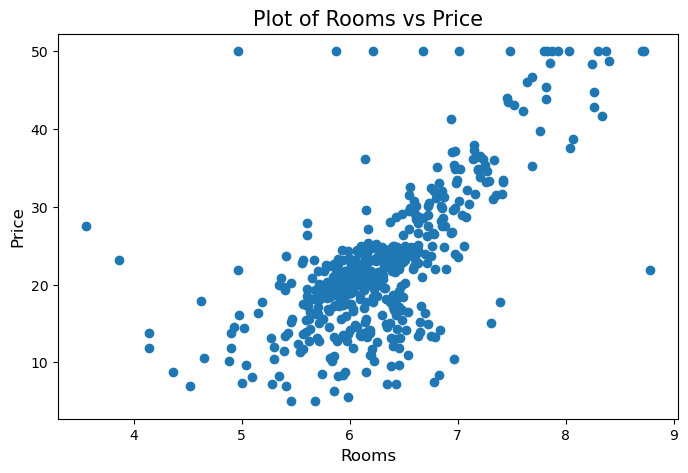

In [14]:
xs = df.Rooms
ys = df.Price

plt.figure(figsize=(8,5))
plt.scatter(xs, ys)
plt.title("Plot of Rooms vs Price", fontsize=15)
plt.xlabel("Rooms", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.show()

In [15]:
corr = np.corrcoef(xs, ys)
print(corr)

[[1.         0.68895429]
 [0.68895429 1.        ]]


#### 2. Low Income
From the scatter plot, we can see that residential areas with a higher percentage of lower income households tend to have lower-priced housing.

The correlation coefficient is -0.738 (3sf), suggesting a very strong negative linear relationship.

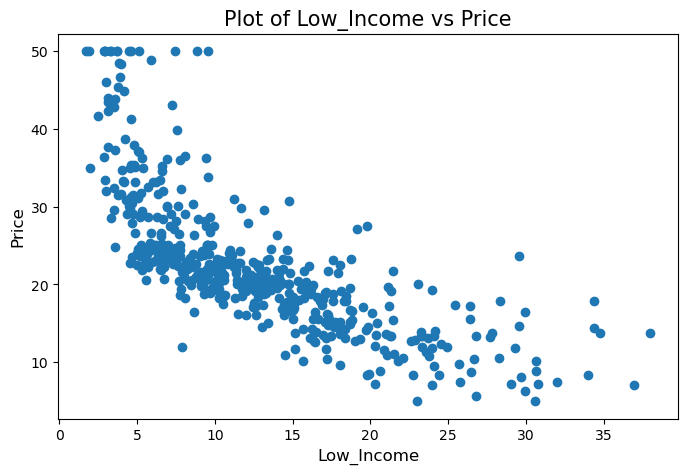

In [16]:
xs = df.Low_Income
ys = df.Price

plt.figure(figsize=(8,5))
plt.scatter(xs, ys)
plt.title("Plot of Low_Income vs Price", fontsize=15)
plt.xlabel("Low_Income", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.show()

In [17]:
corr = np.corrcoef(xs, ys)
print(corr)

[[ 1.         -0.73792378]
 [-0.73792378  1.        ]]


#### 3. Crime Rates
From the table, we can see that a higher crime rate leads to a lower mean price of houses. The boxplot also illustrates this.

This shows that crime rate and price have a negative relationship.

In [18]:
df.groupby('Crime_Rate_Encoded')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Crime_Rate_Encoded,,,,,,,,
0,374.0,24.379679,8.430267,5.6,19.40,22.45,27.800,50.0
1,96.0,17.326042,9.231676,6.3,12.25,14.90,19.925,50.0
2,14.0,9.714286,3.063898,5.0,7.75,10.40,10.800,16.3


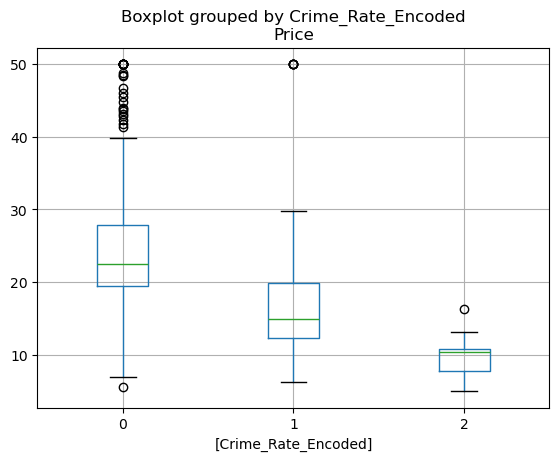

In [19]:
df[['Crime_Rate_Encoded','Price']].boxplot(by='Crime_Rate_Encoded')
plt.show()

#### 4. Pollutants
From the scatter plot, we can see that more polluted residential areas tend to have lower-priced housing.

The correlation coefficient is -0.417 (3sf), suggesting a moderate negative linear relationship.

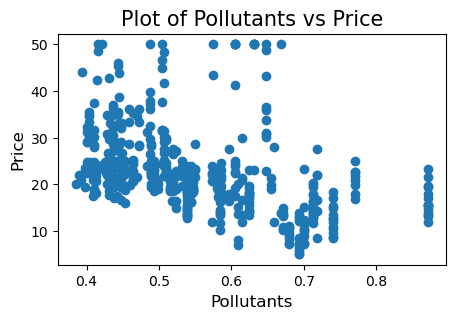

In [20]:
xs = df.Pollutants
ys = df.Price

plt.figure(figsize=(5,3))
plt.scatter(xs, ys)
plt.title("Plot of Pollutants vs Price", fontsize=15)
plt.xlabel("Pollutants", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.show()

In [21]:
corr = np.corrcoef(xs, ys)
print(corr)

[[ 1.         -0.41710631]
 [-0.41710631  1.        ]]


### Variables versus Low Income
Secondly, we analysed the variables that correlate with the percentage of low income households in a residential area.

#### 1. Crime Rate
Both the table and the boxplot strongly suggest that Crime_Rate and Low_Income have a positive relationship.

This means that residential areas with a higher percentage of lower income households also tended to have higher crime rates.

In [22]:
df.groupby('Crime_Rate_Encoded')['Low_Income'].describe()

,count,mean,std,min,25%,50%,75%,max
Crime_Rate_Encoded,,,,,,,,
0,374.0,10.674679,5.841621,1.73,6.3600,9.530,13.9950,34.41
1,96.0,18.430625,6.828324,2.96,14.5050,18.090,22.7750,37.97
2,14.0,24.975714,6.199099,14.52,20.9925,23.515,30.0125,36.98


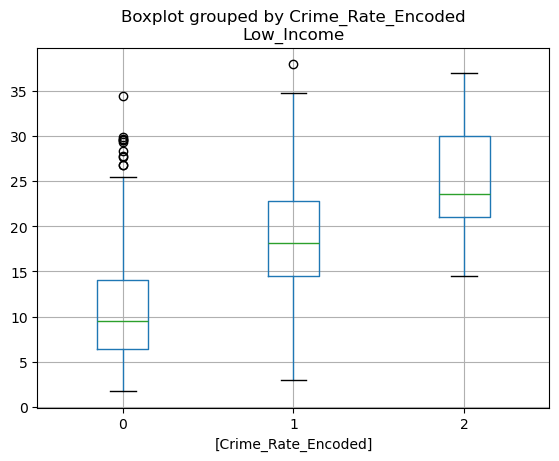

In [23]:
df[['Crime_Rate_Encoded','Low_Income']].boxplot(by='Crime_Rate_Encoded')
plt.show()

#### 2. Pollutants
The scatter plot shows that residential areas with a higher percentage of lower income households also tended to be more polluted.

The correlation coefficient is 0.602 (3sf), suggesting a strong positive linear relationship.

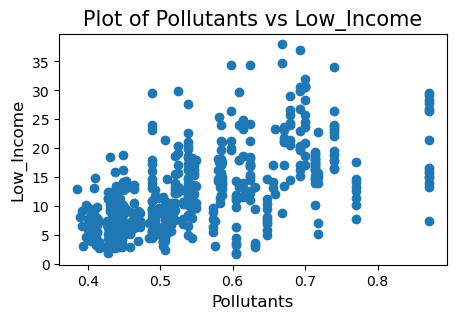

In [24]:
xs = df.Pollutants
ys = df.Low_Income

plt.figure(figsize=(5,3))
plt.scatter(xs, ys)
plt.title("Plot of Pollutants vs Low_Income", fontsize=15)
plt.xlabel("Pollutants", fontsize=12)
plt.ylabel("Low_Income", fontsize=12)
plt.show()

In [25]:
corr = np.corrcoef(xs, ys)
print(corr)

[[1.         0.60175559]
 [0.60175559 1.        ]]


#### 3. Rooms
The scatter plot shows that as Low_Income increases, Rooms decrease.

The correlation coefficient is -0.607, hence it is a moderate positive relationship.

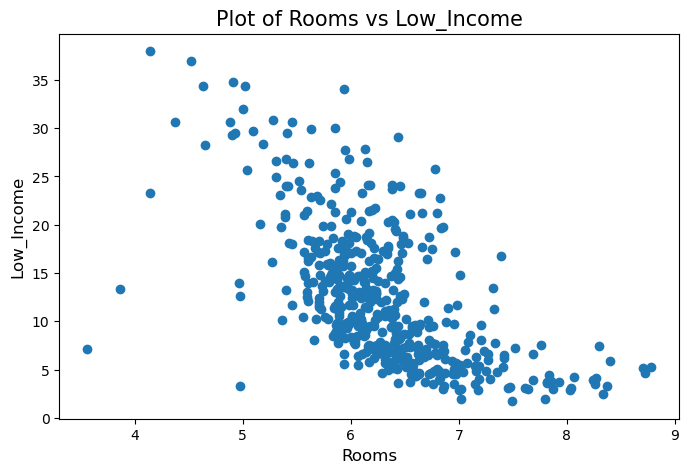

In [26]:
xs = df["Rooms"]
ys = df["Low_Income"]

plt.figure(figsize=(8,5))
plt.scatter(xs, ys)
plt.title("Plot of Rooms vs Low_Income", fontsize=15)
plt.xlabel("Rooms", fontsize=12)
plt.ylabel("Low_Income", fontsize=12)
plt.show()

In [27]:
corr = np.corrcoef(xs, ys)
print(corr)

[[ 1.         -0.61324159]
 [-0.61324159  1.        ]]


#### 4. Student_Teacher_Ratio
The scatter plot shows a positive relationship between Low_Income and Student_Teacher_Ratio.

The correlation coefficient is 0.370, hence it is a moderate positive relationship.

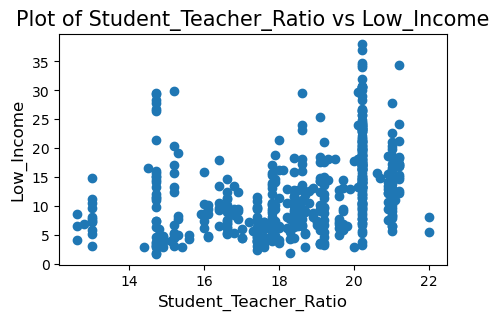

In [28]:
xs = df['Student_Teacher_Ratio']
ys = df.Low_Income

plt.figure(figsize=(5,3))
plt.scatter(xs, ys)
plt.title("Plot of Student_Teacher_Ratio vs Low_Income", fontsize=15)
plt.xlabel('Student_Teacher_Ratio', fontsize=12)
plt.ylabel("Low_Income", fontsize=12)
plt.show()

In [29]:
corr = np.corrcoef(xs, ys)
print(corr)

[[1.         0.36981136]
 [0.36981136 1.        ]]


### Other Relationships

#### 1. Highway_Access versus Pollutants
Both the table and the boxplot shows that as Highway_Access increases, Pollutants increase.

This is likely because more accessible highways lead to more usage of vehicles, which in turn cause more pollution.

In [30]:
df.groupby('Highway_Access_Encoded')['Pollutants'].describe()

,count,mean,std,min,25%,50%,75%,max
Highway_Access_Encoded,,,,,,,,
0,75.0,0.464211,0.054519,0.385,0.429,0.449,0.4880,0.581
1,283.0,0.526013,0.105808,0.398,0.439,0.510,0.5485,0.871
2,126.0,0.673540,0.061173,0.532,0.631,0.693,0.7130,0.770


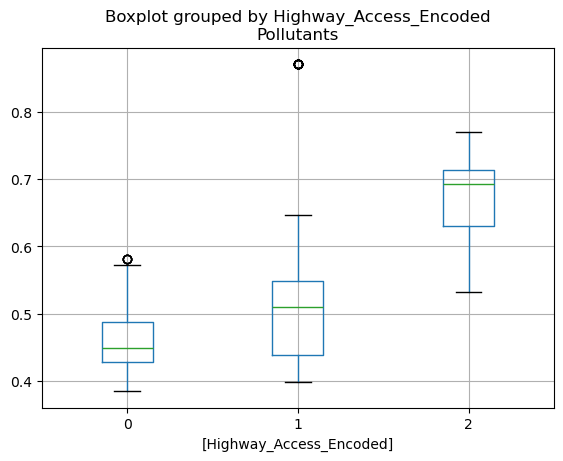

In [31]:
df[['Highway_Access_Encoded','Pollutants']].boxplot(by='Highway_Access_Encoded')
plt.show()